<a href="https://colab.research.google.com/github/Aggarwal45/stock-price-pred/blob/main/stock_xg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

In [10]:

print("Fetching Data...")
stock = 'GOOG'
start = '2012-01-01'
end = '2022-12-31'
data = yf.download(stock, start, end)

df = data[('Close', stock)].to_frame(name='Close')

/tmp/ipykernel_489/3911272693.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed

Fetching Data...


In [11]:

print("Creating Lag Features...")
for i in range(1, 101):
    df[f'Lag_{i}'] = df['Close'].shift(i)
df = df.dropna()

X = df.drop('Close', axis=1)
y = df['Close']


Creating Lag Features...


/tmp/ipykernel_489/208430006.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'Lag_{i}'] = df['Close'].shift(i)


In [12]:

# 3. Train/Test Split (80/20 Split without shuffling to maintain time order)
print("Splitting Data...")
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]



Splitting Data...


In [13]:
# 4. Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)


Training Random Forest...


In [14]:
# 5. Train XGBoost
print("Training XGBoost...")
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

Training XGBoost...


In [15]:
rf_mse = mean_squared_error(y_test, rf_predictions)
xgb_mse = mean_squared_error(y_test, xgb_predictions)

print("-" * 30)
print(f"Random Forest MSE: {rf_mse:.4f}")
print(f"XGBoost MSE:       {xgb_mse:.4f}")
print("-" * 30)

------------------------------
Random Forest MSE: 1304.5662
XGBoost MSE:       1311.0992
------------------------------


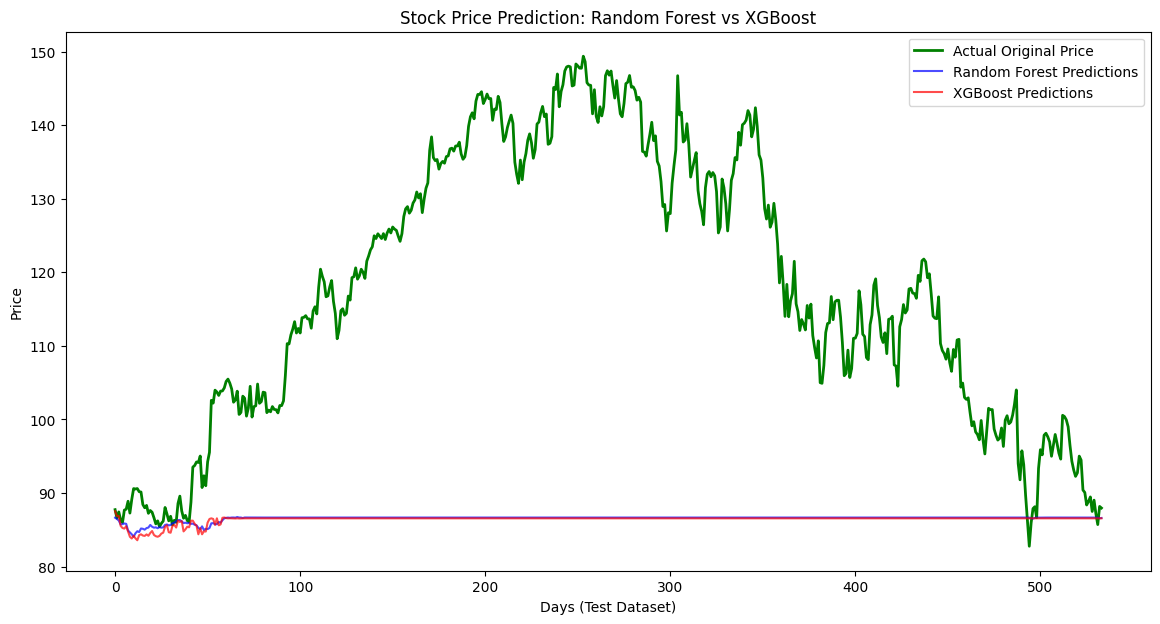

In [16]:
plt.figure(figsize=(14,7))
plt.plot(y_test.values, label='Actual Original Price', color='green', linewidth=2)
plt.plot(rf_predictions, label='Random Forest Predictions', color='blue', alpha=0.7)
plt.plot(xgb_predictions, label='XGBoost Predictions', color='red', alpha=0.7)

plt.title('Stock Price Prediction: Random Forest vs XGBoost')
plt.xlabel('Days (Test Dataset)')
plt.ylabel('Price')
plt.legend()
plt.show()